# 1. Configuración de Librerías

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración de gráficos
sns.set_theme(style='whitegrid')
print('Librerías listas para la acción.')

Librerías listas para la acción.


## 2. Ingesta de Datos
Cargamos el dataset original y realizamos una copia de seguridad en nuestra estructura de carpetas local.

In [5]:
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Guardamos backup en la carpeta raw
df.to_csv('../../data/raw/titanic_original.csv', index=False)
print('Archivo original a salvo en data/raw.')

Archivo original a salvo en data/raw.


## 3. Diagnóstico de Calidad
Analizamos la presencia de valores nulos y tipos de datos para decidir nuestra estrategia de limpieza.

In [6]:
print('--- Conteo de Nulos ---')
print(df.isnull().sum())

print('\n--- Porcentaje de Nulos ---')
print((df.isnull().sum() / len(df)) * 100)

--- Conteo de Nulos ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

--- Porcentaje de Nulos ---
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


## 4. Cirugía de Datos

In [9]:
# 1. Imputación de valores faltantes
# Usamos asignación directa para evitar el ChainedAssignmentError
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 2. Eliminación de columnas no deseadas
# El parámetro errors='ignore' evita que el código falle si las columnas ya han sido borradas
columnas_a_eliminar = ['Cabin', 'PassengerId', 'Ticket', 'Name']
df.drop(columns=columnas_a_eliminar, inplace=True, errors='ignore')

# 3. Verificación final
print("--- Cirugía completada con éxito ---")
print(f"Filas resultantes: {df.shape[0]}")
print(f"Columnas resultantes: {df.shape[1]}")
print("\nConteo de nulos tras la limpieza:")
print(df.isnull().sum())

--- Cirugía completada con éxito ---
Filas resultantes: 891
Columnas resultantes: 8

Conteo de nulos tras la limpieza:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


## 5. Exportación a Processed
Guardamos el archivo final limpio para que otros notebooks o modelos puedan consumirlo con seguridad.

In [10]:
df.to_csv('../../data/processed/titanic_limpio.csv', index=False)
print('Dataset exportado con éxito.')

Dataset exportado con éxito.


## 6. Análisis Exploratorio (EDA): Distribuciones Iniciales
En esta fase analizamos las variables de forma individual. Buscamos entender el equilibrio de nuestra variable objetivo (`Survived`) y la demografía del barco.

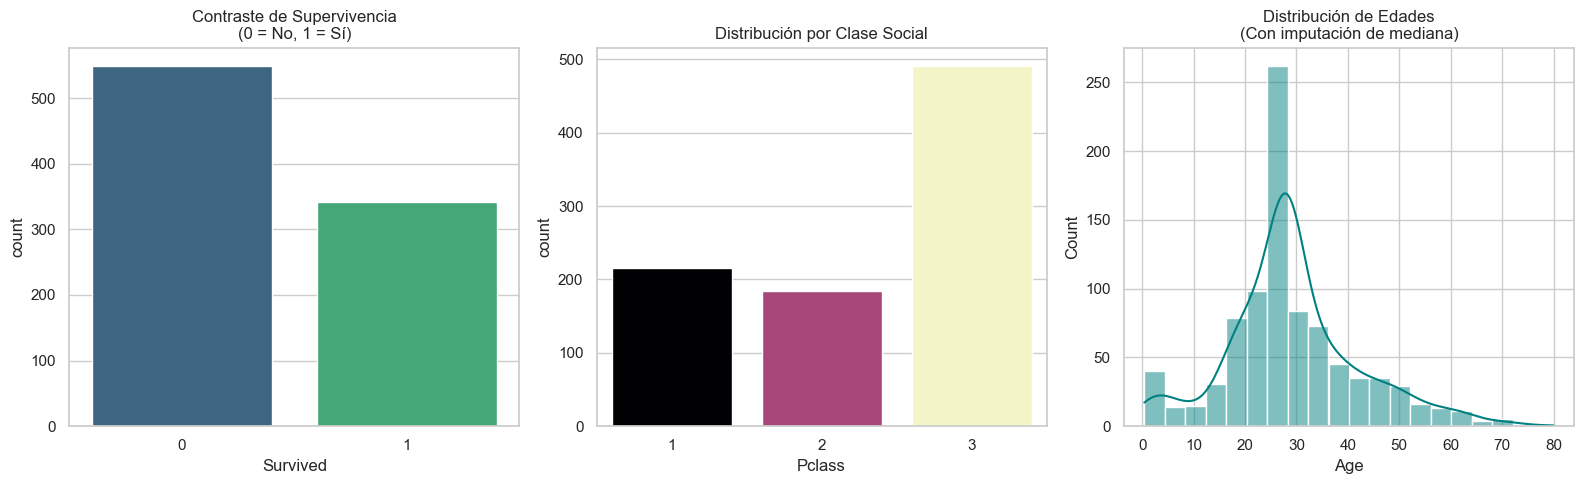

In [11]:
# Configuramos un estilo visual profesional
sns.set_theme(style="whitegrid", palette="muted")
plt.figure(figsize=(16, 5))

# 1. ¿Cuántos sobrevivieron? (Variable Objetivo)
plt.subplot(1, 3, 1)
sns.countplot(x='Survived', data=df, hue='Survived', palette='viridis', legend=False)
plt.title('Contraste de Supervivencia\n(0 = No, 1 = Sí)')

# 2. ¿En qué clase viajaban?
plt.subplot(1, 3, 2)
sns.countplot(x='Pclass', data=df, hue='Pclass', palette='magma', legend=False)
plt.title('Distribución por Clase Social')

# 3. ¿Qué edades había en el barco?
plt.subplot(1, 3, 3)
sns.histplot(data=df, x='Age', bins=20, kde=True, color='teal')
plt.title('Distribución de Edades\n(Con imputación de mediana)')

plt.tight_layout()
plt.show()

## 7. Análisis Bivariante: El factor de la Clase y el Género
Cruzamos nuestra variable objetivo (`Survived`) con los predictores más potentes. 
* **Hipótesis 1:** Las mujeres tuvieron una tasa de supervivencia significativamente mayor.
* **Hipótesis 2:** Los pasajeros de primera clase fueron priorizados en los botes.

C:\Users\txema\AppData\Local\Temp\ipykernel_15012\1902568047.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, palette='Blues', ci=None)
C:\Users\txema\AppData\Local\Temp\ipykernel_15012\1902568047.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, palette='Blues', ci=None)
C:\Users\txema\AppData\Local\Temp\ipykernel_15012\1902568047.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, palette='Oranges', ci=None)
C:\Users\txema\AppData\Local\Temp\ipykernel_15012\1902568047.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` an

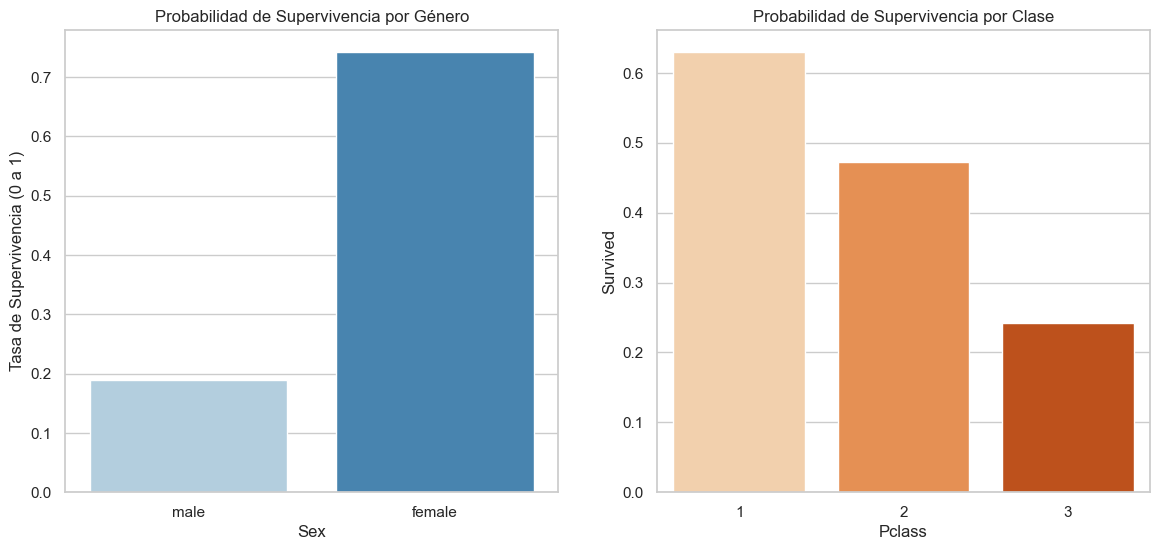

In [12]:
plt.figure(figsize=(14, 6))

# 1. Supervivencia por Género
plt.subplot(1, 2, 1)
sns.barplot(x='Sex', y='Survived', data=df, palette='Blues', ci=None)
plt.title('Probabilidad de Supervivencia por Género')
plt.ylabel('Tasa de Supervivencia (0 a 1)')

# 2. Supervivencia por Clase
plt.subplot(1, 2, 2)
sns.barplot(x='Pclass', y='Survived', data=df, palette='Oranges', ci=None)
plt.title('Probabilidad de Supervivencia por Clase')

plt.show()